# Q2. Unsupervised Learning

## 1. Data Preparation

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [7]:
# Load Data
df= pd.read_csv("C:/Users/Shivangi/OneDrive/Desktop/assignment 4 A and B/q2_customers.csv")
#Scale Features
scaler= StandardScaler()
scaled_data = scaler.fit_transform(df)

Why Scaling is Required:

K-Means clustering is based on distance (Euclidean distance), so features with larger values (e.g., annual_spend) would dominate smaller ones (e.g., visits_per_month)

Scaling ensures that all features contribute equally to cluster formation

Without scaling, the clustering results would be biased and misleading



## 2. Elbow Method

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

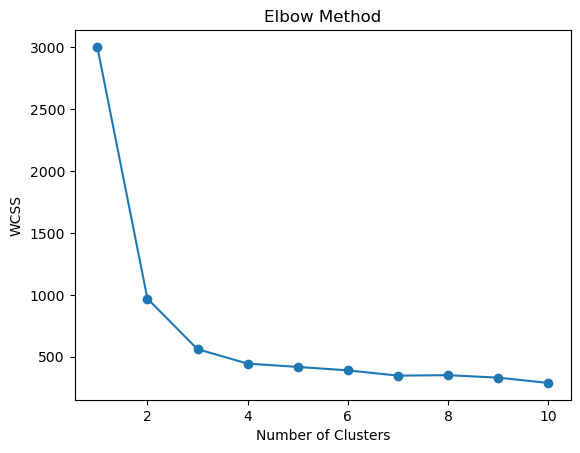

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Choosing Optimal K  
The elbow point appears at K = 3, where the reduction in WCSS starts to slow down significantly.  
This indicates that adding more clusters beyond this point does not provide substantial improvement.  
Therefore, K = 3 is chosen as the optimal number of clusters.

## 3. K-Means Clustering

In [10]:
# Fit model
kmeans = KMeans(n_clusters=3, random_state=42)  # replace 3 with K
df['cluster'] = kmeans.fit_predict(scaled_data)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0:
Customers in this segment are young (avg age 25), low spenders (14.8k), but highly active (14 visits/month) with small basket sizes and low category diversity.
 These are frequent low-value customers who engage regularly but contribute less per transaction.
 Business Strategy: Upsell and bundle offers can increase their basket size and overall spend.

Cluster 1:
Customers are older (57), extremely high spenders (89k), but visit very infrequently (2.5 visits/month) with very large basket sizes and high category diversity.
 These are premium, high-value customers who make bulk purchases occasionally.
 Business Strategy: Retention is critical — offer loyalty programs, exclusive deals, and personalized recommendations.

Cluster 2:
Customers fall in the middle age group (40), with moderate spending (43k), moderate visit frequency (8/month), and balanced basket size and category diversity.
 These are regular, balanced customers with stable purchasing behavior.
 Business Strategy: Encourage cross-selling and personalized promotions to gradually move them toward high-value segments.


## 4. PCA

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 is primarily influenced by features like annual_spend and basket_size, indicating that it represents customer spending behavior

PC2 is influenced by features such as visits_per_month and days_since_last_visit, representing customer engagement and activity level

Together, PC1 and PC2 capture the major variation in customer behavior, allowing effective visualization of clusters

## 5. Cluster Visualization

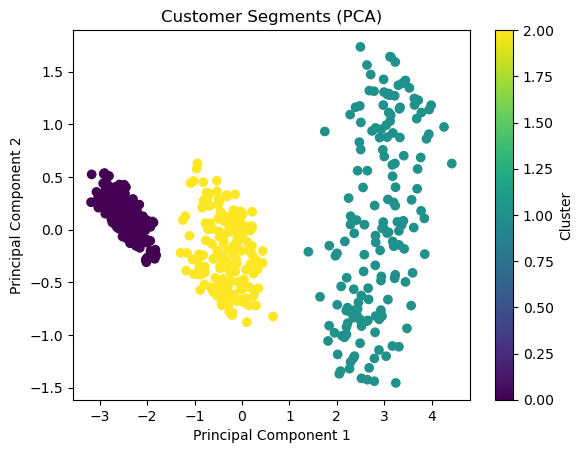

In [13]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

The clusters appear well-separated. 
This indicates that customer groups are distinct